##### 배경, 안피부 제거

In [1]:
# h, w, _ = np_image.shape

In [8]:
# mp로 이미지 로드, PIL로 jpg 저장
# non-skin 제거 (v0.3)

import matplotlib.pyplot as plt
import cv2
import sys

sys.path.append('/home/work/hocheol_dir/workspace/_dataset')
from preprocess.remove_non_skin import remove_non_skin
from preprocess.pigment_data.crop_mp import crop_cheeks_from_np_image
from utils.Mediapipe import MediaPipe

face_landmarker = MediaPipe()

IMAGE_PATH = '/home/work/hocheol_dir/workspace/_dataset/datasets/_origin_data/999_data/data/6158_6_L.jpg'
with open(IMAGE_PATH, 'rb') as f:
    img_bytes = f.read()
mp_image = face_landmarker.create_mp_image(img_bytes)
detection_results = face_landmarker.landmarker.detect(mp_image)
detection_results
# landmarks = detection_results.face_landmarks[0]

# np_image = mp_image.numpy_view()
# masked_image = remove_non_skin(np_image, landmarks)

# left_cheek, right_cheek = crop_cheeks_from_np_image(np_image, landmarks)

# fig, ax = plt.subplots(2, 2, figsize=(8,8))

# ax[0][0].imshow(np_image)
# ax[0][1].imshow(masked_image)

# if 0 not in left_cheek.shape:
#     ax[1][0].imshow(left_cheek)

# if 0 not in right_cheek.shape:
#     ax[1][1].imshow(right_cheek)

# plt.show()

I0000 00:00:1759745408.268230 1419647 task_runner.cc:85] GPU suport is not available: INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:84) egl_initializedUnable to initialize EGL
W0000 00:00:1759745408.270675 1419647 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1759745408.296765 1420514 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1759745408.328068 1420520 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1759745413.296259 1420518 landmark_projection_calculator.cc:186] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


FaceLandmarkerResult(face_landmarks=[], face_blendshapes=[], facial_transformation_matrixes=[])

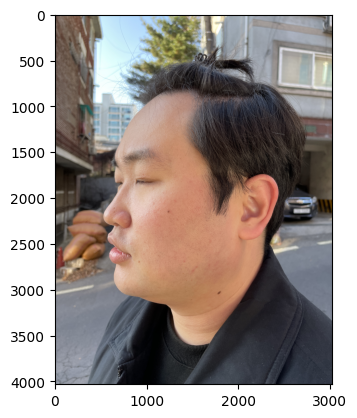

In [32]:
import cv2

img = cv2.imread(IMAGE_PATH)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.show()

In [5]:
# # v0.3에서 라벨 베껴오기
# import json
# import os
# import shutil

# source_json = '/home/work/hocheol_dir/workspace/_dataset/datasets/pigment_data/v0.3/v0.3_data/pig_label_paths.json'
# target_json = source_json.replace('/v0.3/', '/v0.4/').replace('/v0.3_data/', '/v0.4.0/')

# source_dirs = []
# target_dirs = []

# with open(source_json, 'r') as f:
#     for path in json.load(f):
#         source_dirs.append(path)
#         target_dirs.append(path.replace('/v0.3/', '/v0.4/').replace('/v0.3_data/', '/v0.4.0/'))

# with open(target_json, 'w') as f:
#     json.dump(target_dirs, f, indent=2, ensure_ascii=False)
    
# # source_dirs, target_dirs


# image_root = '/home/work/hocheol_dir/workspace/_dataset/datasets/_origin_data'
# for source_dir, target_dir in zip(source_dirs, target_dirs):
#     for json_file in os.listdir(source_dir):
#         source_path = os.path.join(source_dir, json_file)
#         target_path = os.path.join(target_dir, json_file)
#         # print(source_path)
#         # print(target_path)

#         os.makedirs(os.path.dirname(target_path), exist_ok=True)
#         print(shutil.copy2(source_path, target_path))

In [1]:
import json
import os

with open('/home/work/hocheol_dir/workspace/_dataset/datasets/pigment_data/v0.4/v0.4.0/pig_label_paths.json', 'r') as f:
    label_paths = json.load(f)
    
json_data = []

for e in label_paths:
    for step in ['train', 'val', 'test']:
        file_path = os.path.join(e, f"pig_{step}.json")
        with open(file_path, 'r') as f:
            json_data.extend(json.load(f))
len(json_data)

20639

In [2]:
img_paths = []
for data in json_data:
    from_left_path = data['left_path'].replace('left_', '') if data['left_path'] is not None else None
    from_right_path = data['right_path'].replace('right_', '') if data['right_path'] is not None else None
    if from_left_path and from_right_path:
        if from_left_path == from_right_path:
            img_paths.append(from_left_path)
        else:
            img_paths.append(from_left_path)
            img_paths.append(from_right_path)
    elif from_left_path:
        img_paths.append(from_left_path)
    elif from_right_path:
        img_paths.append(from_right_path)
len(img_paths)

26410

In [ ]:
'''
single processing
'''
# import sys
# sys.path.append('/home/work/hocheol_dir/workspace/_dataset')
# from preprocess.remove_non_skin import remove_non_skin
# from utils.Mediapipe import MediaPipe
# from preprocess.pigment_data.crop_mp import crop_cheeks_from_np_image
# from PIL import Image
# import os
# import matplotlib.pyplot as plt
# from tqdm import tqdm
# import re
# from utils.slack import send_slack_message
# from multiprocessing import Pool, current_process

# target_root = '/home/work/hocheol_dir/workspace/_dataset/datasets/pigment_data/v0.4/v0.4_data'
# origin_root = '/home/work/hocheol_dir/workspace/_dataset/datasets/_origin_data'

# face_landmarker = MediaPipe()

# fail_list = []

# for img_path in tqdm(img_paths):

#     origin_path = os.path.join(origin_root, img_path)
#     target_path = os.path.join(target_root, img_path)

#     if os.path.exists(target_path):
#         continue
#     else:
#         # image = cv2.imread(origin_path)
#         with open(origin_path, 'rb') as f:
#             img_bytes = f.read()
#             mp_image = face_landmarker.create_mp_image(img_bytes)
#         np_image = mp_image.numpy_view()
#         detection_results = face_landmarker.landmarker.detect(mp_image)
#         landmarks = detection_results.face_landmarks[0]

#         masked_image = remove_non_skin(np_image, landmarks)

#         left_cheek, right_cheek = crop_cheeks_from_np_image(masked_image, landmarks)

#         left_path = re.sub(r"_data/data/", r"_data/data/left_", target_path)
#         left_path = os.path.splitext(left_path)[0] + ".jpg"

#         right_path = re.sub(r"_data/data/", r"_data/data/right_", target_path)
#         right_path = os.path.splitext(right_path)[0] + ".jpg"

#         os.makedirs(os.path.dirname(left_path), exist_ok=True)

#         try:
#             Image.fromarray(left_cheek).save(left_path)
#         except:
#             print(f"Error saving image: {left_path}")
#             fail_list.append(left_path)
#         try:
#             Image.fromarray(right_cheek).save(right_path)
#         except:
#             print(f"Error saving image: {right_path}")
#             fail_list.append(right_path)

# print(f"Failed to save {len(fail_list)} images.")

In [5]:
'''
multi processing
'''
import sys
from multiprocessing import get_context
from utils.slack import send_slack_message
from tqdm import tqdm
import os

sys.path.append('/home/work/hocheol_dir/workspace/_dataset/preprocess/pigment_data/v0.4/v0.4.0')
from worker import initializer, process_image

NUM_CORES = 1

try:
    with get_context("spawn").Pool(processes=NUM_CORES, initializer=initializer) as pool:
        results = list(tqdm(pool.imap_unordered(process_image, img_paths), total=len(img_paths)))
    # 성공/실패/건너뛰기 결과 요약
    success_count = sum(1 for r in results if r.startswith("processed"))
    skipped_count = sum(1 for r in results if r.startswith("skipped"))
    failed_count = sum(1 for r in results if r.startswith("failed"))
    
    # 실패 목록만 따로 저장 (디버깅용)
    fail_list = [r for r in results if r.startswith("failed")]

    summary_message = (
        "Pigment Data Preprocessing Finished!\n"
        f"Total: {len(img_paths)}\n"
        f"processed: {success_count}\n"
        f"skipped: {skipped_count}\n"
        f"failed: {failed_count}"
    )
    print(summary_message)
    print("\n--- failed List ---")
    for fail_item in fail_list:
        print(fail_item)
    # send_slack_message(summary_message) # 필요 시 주석 해제

except Exception as e:
    error_message = f"Pigment preprocess main error: {e}"
    print(error_message)
    # send_slack_message(error_message) # 필요 시 주석 해제
    raise e


  0%|                                                                                                                                 | 0/26410 [00:00<?, ?it/s]

2025-10-06 18:33:07.601788: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9373] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-10-06 18:33:07.601828: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-10-06 18:33:07.603323: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1534] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
I0000 00:00:1759743190.578675 1420376 task_runner.cc:85] GPU suport is not available: INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:84) egl_initializedUnable to initialize EGL
W0000 00:00:1759743190.579472 1420376 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
INFO: Created TensorFlow Lite XNNPACK dele

Initializing MediaPipe for process: SpawnPoolWorker-9


 59%|███████████████████████████████████████████████████████████████████▍                                               | 15497/26410 [00:17<00:09, 1175.10it/s]W0000 00:00:1759743207.016156 1420440 landmark_projection_calculator.cc:186] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.
/usr/local/lib/python3.10/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 26410/26410 [02:22<00:00, 185.21it/s]

Pigment Data Preprocessing Finished!
Total: 26410
processed: 0
skipped: 26375
failed: 13

--- failed List ---
failed (no landmarks): 045_data/data/F0102_IND_GM_76_45_02.JPG
failed (no landmarks): 045_data/data/F0161_IND_S_35_-45_02.JPG
failed (no landmarks): 045_data/data/F0208_IND_D_19_45_02.JPG
failed (no landmarks): 045_data/data/F0851_IND_M_36_-45_01.JPG
failed (no landmarks): 045_data/data/F0852_IND_M_41_-45_02.jpg
failed (no landmarks): 045_data/data/F0157_IND_D_11_-45_01.JPG
failed (no landmarks): 045_data/data/F0161_IND_F_65_-45_01.JPG
failed (no landmarks): 999_data/data/6158_6_L.jpg
failed (no landmarks): 999_data/data/6167_4_R.jpg
failed (no landmarks): 999_data/data/6258_7_R_2.jpg
failed (no landmarks): 999_data/data/6270_7_R.jpg
failed (no landmarks): 999_data/data/6271_7_L.jpg
failed (no landmarks): 999_data/data/6207_5_R.jpg


In [11]:
TARGET_ROOT = '/home/work/hocheol_dir/workspace/_dataset/datasets/pigment_data/v0.4/v0.4_data'
ORIGIN_ROOT = '/home/work/hocheol_dir/workspace/_dataset/datasets/_origin_data'
EXT_ROOT = '/home/work/hocheol_dir/workspace/_dataset/datasets/pigment_data/v0.3/v0.3_data'

In [12]:
import re

lst = []

def get_paths(path):
    catch = re.search(r"/data/.*\..*", path).group()
    left = catch.replace('/data/', '/data/left_')
    right = catch.replace('/data/', '/data/right_')

    left_path = os.path.join(TARGET_ROOT, path.replace(catch, left))
    right_path = os.path.join(TARGET_ROOT, path.replace(catch, right))

    return left_path, right_path

for path in img_paths:
    left_path, right_path = get_paths(path)

    if not os.path.exists(left_path):
        lst.append(left_path)
    if not os.path.exists(right_path):
        lst.append(right_path)

len(img_paths), len(lst)

(26410, 48)

In [ ]:
############################ 라벨 있고 전처리 안된 데이터 빼야겠제?

In [5]:
# v0.4.1로 만들까

In [6]:
import json

origin_dirs_path = '/home/work/hocheol_dir/workspace/_dataset/datasets/pigment_data/v0.4/v0.4.0/pig_label_paths.json'
with open(origin_dirs_path, 'r') as f:
    origin_dirs = json.load(f)

new_dirs = []
for origin_dir in origin_dirs:
    new_dirs.append(origin_dir.replace('v0.4.0', 'v0.4.1'))

In [ ]:
image_root = '/home/work/hocheol_dir/workspace/_dataset/datasets/pigment_data/v0.4/v0.4_data'

for origin_dir, new_dir in zip(origin_dirs, new_dirs):
    print(origin_dir)
    for step in ['train', 'val', 'test']:
        origin_path = os.path.join(origin_dir, f"pig_{step}.json")
        new_path = os.path.join(new_dir, f"pig_{step}.json")

        with open(origin_path, 'r') as f:
            json_data = json.load(f)
        
        new_data = []

        left, right = 0, 0
        for data in json_data:
            left_path = os.path.join(image_root, data['left_path']) if data['left_path'] else ''
            right_path = os.path.join(image_root, data['right_path']) if data['right_path'] else ''

            if not os.path.exists(left_path):
                left += 1
                left_path = ''
            if not os.path.exists(right_path):
                right += 1
                right_path = ''
            
            data['left_path'] = left_path.replace(image_root + "/", '')
            data['right_path'] = right_path.replace(image_root + "/", '')

            new_data.append(data)
        
        print(f"left: {left}, right: {right}, total: {len(new_data)}")

        os.makedirs(os.path.dirname(new_path), exist_ok=True)
        with open(new_path, 'w') as f:
            json.dump(new_data, f, indent=2, ensure_ascii=False)


/home/work/hocheol_dir/workspace/_dataset/datasets/pigment_data/v0.4/v0.4.0/028_data/label
left: 0, right: 0, total: 3860
left: 0, right: 0, total: 480
left: 0, right: 0, total: 485
/home/work/hocheol_dir/workspace/_dataset/datasets/pigment_data/v0.4/v0.4.0/030_data/label
left: 0, right: 0, total: 1299
left: 0, right: 0, total: 162
left: 0, right: 0, total: 163
/home/work/hocheol_dir/workspace/_dataset/datasets/pigment_data/v0.4/v0.4.0/034_data/label
left: 0, right: 0, total: 4280
left: 0, right: 0, total: 534
left: 0, right: 0, total: 536
/home/work/hocheol_dir/workspace/_dataset/datasets/pigment_data/v0.4/v0.4.0/045_data/label
left: 136, right: 63, total: 2657
left: 55, right: 17, total: 372
left: 6, right: 5, total: 327
/home/work/hocheol_dir/workspace/_dataset/datasets/pigment_data/v0.4/v0.4.0/118_data/label
left: 0, right: 0, total: 620
left: 0, right: 0, total: 70
left: 0, right: 0, total: 85
/home/work/hocheol_dir/workspace/_dataset/datasets/pigment_data/v0.4/v0.4.0/999_data/lab